# Поиск частых наборов

Разработайте программу, которая выполняет поиск частых наборов объектов в заданном наборе данных с помощью алгоритма Apriori (или одной из его модификаций). Список результирующих наборов должен содержать как наборы, так и значение поддержки для каждого набора. Параметрами программы являются набор, порог поддержки и способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).

Проведите эксперименты на наборе данных baskets.csv (сведения о покупках в супермаркете). В экспериментах варьируйте пороговое значение поддержки (например: 1%, 3%, 5%, 10%, 15%).

Выполните визуализацию результатов экспериментов в виде следующих диаграмм:
 - сравнение быстродействия на фиксированном наборе данных при изменяемом пороге поддержки;
 - количество частых наборов объектов различной длины на фиксированном наборе данных при изменяемом пороге поддержки.

Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
 - формулировка задания;
 - гиперссылка на каталог репозитория с исходными текстами, наборами данных и др. сопутствующими материалами;
 - рисунки с результатами визуализации;
 - пояснения, раскрывающие смысл полученных результатов.

# Подключение библиотек

In [4]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
import pandas as pd
import chardet
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
import time
import matplotlib.pyplot as plt

# Получение данных

In [10]:
df = pd.read_csv('baskets.csv', header=None, encoding='cp1251')
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,креветки,миндаль,авокадо,овощная смесь,зеленый виноград,цельнозерновая мука,батат,творог,энергетический напиток,томатный сок,низкокалорийный йогурт,зеленый чай,мед,салат,минеральная вода,лосось,ягодный сок,замороженный смузи,шпинат,оливковое масло
1,гамбургер,фрикадельки,яйца,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,чатни,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,индейка,авокадо,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,минеральная вода,молоко,энергетический батончик,рис,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,сливочное масло,низкокалорийный майонез,свежий хлеб,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,гамбургер,замороженные овощи,яйца,картофель-фри,журнал,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,курица,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,эскалоп,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим пустые строки, столбцы. Сформируем список транзакций

In [12]:
df = df.dropna(how="all", axis=0)
df = df.dropna(how="all", axis=1)

transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
print("Всего транзакций: %d" % len(transactions))
print(transactions[:5])

Всего транзакций: 7501
[['креветки', 'миндаль', 'авокадо', 'овощная смесь', 'зеленый виноград', 'цельнозерновая мука', 'батат', 'творог', 'энергетический напиток', 'томатный сок', 'низкокалорийный йогурт', 'зеленый чай', 'мед', 'салат', 'минеральная вода', 'лосось', 'ягодный сок', 'замороженный смузи', 'шпинат', 'оливковое масло'], ['гамбургер', 'фрикадельки', 'яйца'], ['чатни'], ['индейка', 'авокадо'], ['минеральная вода', 'молоко', 'энергетический батончик', 'рис', 'зеленый чай']]


Функция apriori() из mlxtend не работает с текстом. Ей нужна матрица булевых значений, чтобы мгновенно выполнятьAND при подсчете совместных покупок.

In [20]:
te = TransactionEncoder()
te_transformed = te.fit(transactions).transform(transactions)
df_transformed = pd.DataFrame(te_transformed, columns=te.columns_)
df_transformed

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [14]:
support_thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]
execution_times = []
results_list = []

for threshold in support_thresholds:
    start_time = time.time()

    frequent_itemsets = apriori(df_transformed, min_support=threshold, use_colnames=True)

    execution_times.append(time.time() - start_time)

    single_items = frequent_itemsets[frequent_itemsets["itemsets"].apply(len) == 1].copy()
    single_items["support_threshold"] = threshold
    results_list.append(single_items)

results_df = pd.concat(results_list, ignore_index=True)
results_df = results_df.sort_values(by=["support_threshold", "support"], ascending=[True, False])

display(results_df)

,support,itemsets,support_threshold
31,0.238368,(минеральная вода),0.01
26,0.187975,(макароны),0.01
73,0.179709,(яйца),0.01
20,0.170911,(картофель-фри),0.01
69,0.163845,(шоколад),0.01
...,...,...,...
144,0.238368,(минеральная вода),0.15
143,0.187975,(макароны),0.15
146,0.179709,(яйца),0.15
142,0.170911,(картофель-фри),0.15


Согласно полученному результату и показателю support, наиболее популярными товарами являются "минеральная вода", "макароны" и "яйца"

Построим график зависимости времени выполнения от порога поддержки

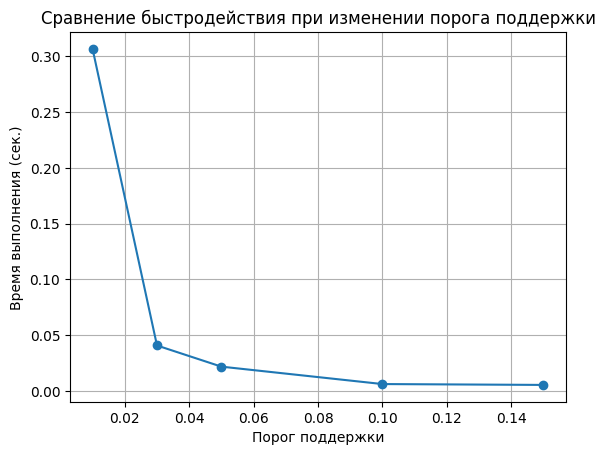

In [15]:
plt.plot(support_thresholds, execution_times, marker="o")
plt.title("Сравнение быстродействия при изменении порога поддержки")
plt.xlabel("Порог поддержки")
plt.ylabel("Время выполнения (сек.)")
plt.grid(True)
plt.show()

На графике сначала наблюдается резкое снижение времени выполнения при увеличении порога поддержки, после чего оно стабилизируется. Это говорит о том, что при увеличении порога поддержки, алгоритм Apriori работает быстрее, так как количество частых наборов для проверки уменьшается

In [17]:
frequent_itemsets_3 = apriori(df_transformed, min_support=0.01, use_colnames=True, max_len=3)
frequent_itemsets_3 = frequent_itemsets_3.sort_values(by="support", ascending=False)
frequent_itemsets_3 = frequent_itemsets_3[frequent_itemsets_3["itemsets"].apply(lambda x: len(x) == 3)]
frequent_itemsets_3

,support,itemsets
245,0.017198,"(говяжий фарш, минеральная вода, макароны)"
254,0.016398,"(шоколад, минеральная вода, макароны)"
252,0.016131,"(минеральная вода, макароны, молоко)"
255,0.015198,"(яйца, минеральная вода, макароны)"
258,0.013998,"(шоколад, минеральная вода, молоко)"
260,0.013465,"(яйца, шоколад, минеральная вода)"
259,0.013065,"(яйца, минеральная вода, молоко)"
249,0.012265,"(замороженные овощи, минеральная вода, макароны)"
244,0.011732,"(минеральная вода, блинчики, макароны)"
256,0.011199,"(шоколад, макароны, молоко)"


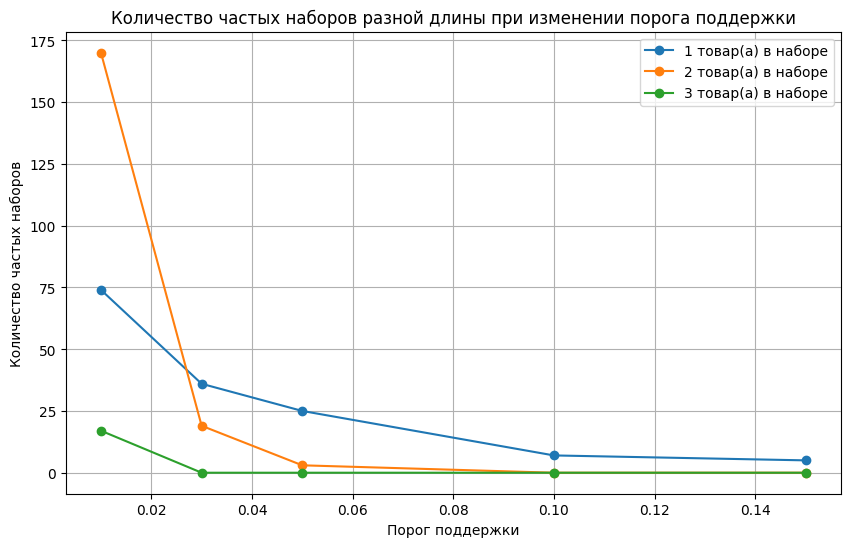

In [19]:
support_thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]
execution_times = []
itemsets_sizes = {1: [], 2: [], 3: []}
all_results = []

for threshold in support_thresholds:
    start_time = time.time()

    frequent_itemsets = apriori(df_transformed, min_support=threshold, use_colnames=True)

    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

    for length in [1, 2, 3]:
        subset = frequent_itemsets[frequent_itemsets['length'] == length].copy()
        subset['support_threshold'] = threshold

        itemsets_sizes[length].append(len(subset))
        all_results.append(subset)

    execution_times.append(time.time() - start_time)

results_df = pd.concat(all_results, ignore_index=True)
results_df = results_df.sort_values(by=["support_threshold", "support"], ascending=[True, False])

plt.figure(figsize=(10, 6))
for length in [1, 2, 3]:
    plt.plot(support_thresholds, itemsets_sizes[length], marker="o", label=f"{length} товар(а) в наборе")

plt.title("Количество частых наборов разной длины при изменении порога поддержки")
plt.xlabel("Порог поддержки")
plt.ylabel("Количество частых наборов")
plt.legend()
plt.grid(True)
plt.show()

На графике видно, что с увеличение порога поддержи уменьшается число наборов, также заметно уменьшение количества элементов в наборе